# LuminaFlux
***Bit depth expansion using signal processing techniques***




In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
from src.image_generator import combine_primary_gradients

# Enable inline static plots
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
from src.visualization import visualize_bde_results

print("Visualization helper successfully moved to src/visualization.py and imported.")

Visualization helper successfully moved to src/visualization.py and imported.


In [10]:
from src.image_generator import combine_primary_gradients, apply_s_curve_contrast_numpy

# 1. Generate 32-bit Reference Gradient (Smooth)
grad_32f = combine_primary_gradients(width=512, height=64, dtype="float32")

# 2. Simulate 8-bit Quantization (NumPy only)
# Round to 255 levels and scale back to [0, 1]
grad_8u_sim = np.round(grad_32f * 255.0).astype(np.float32) / 255.0


Input shape: (3, 579, 512)
Output shape: (3, 579, 512)


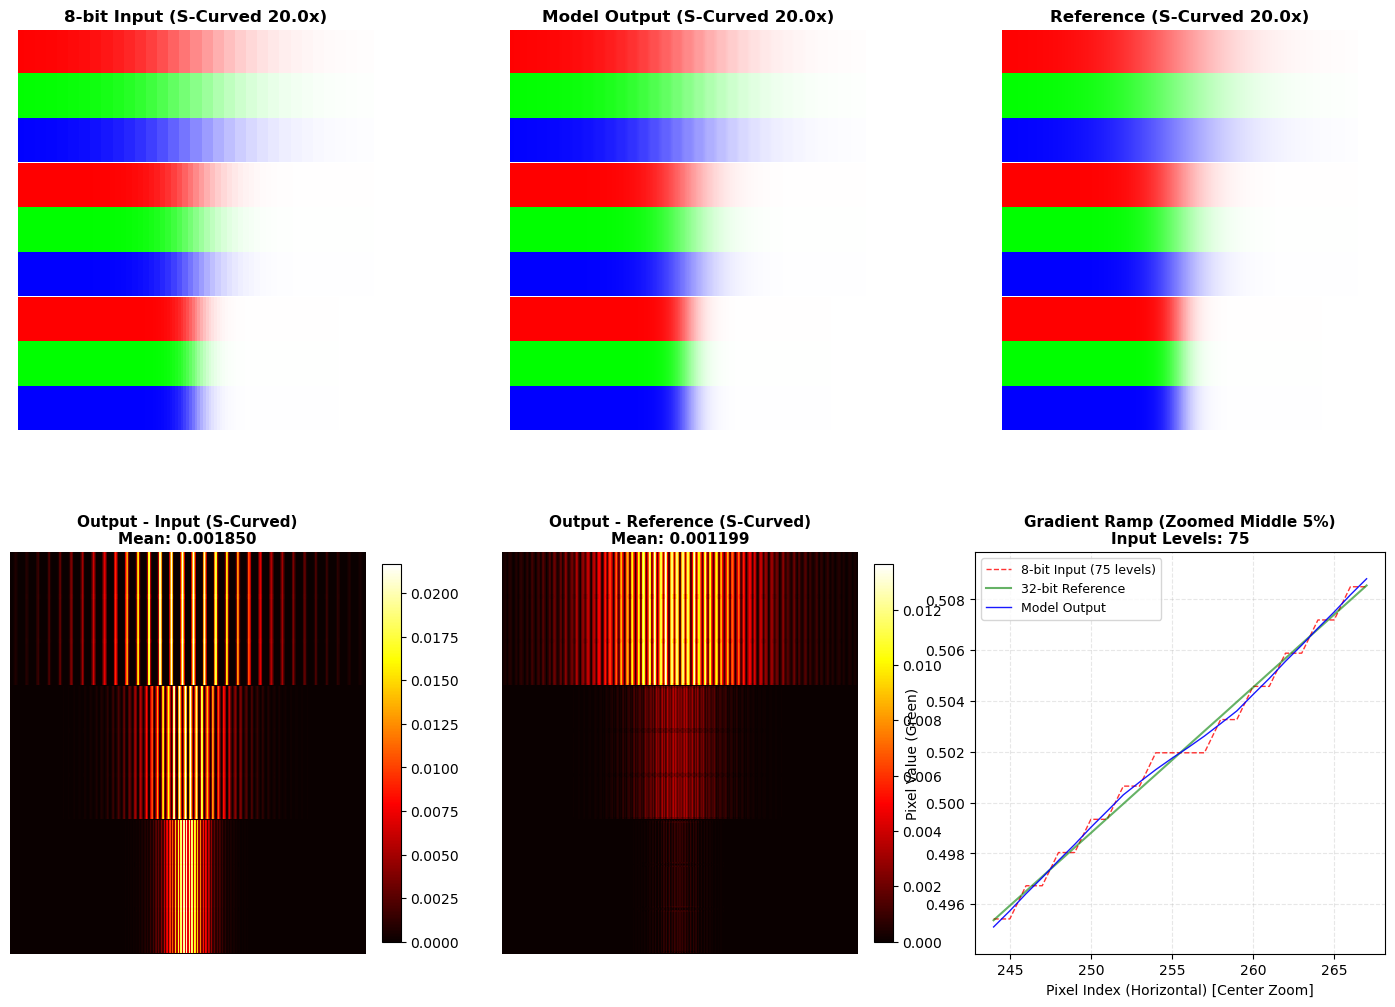

In [11]:
# Bilateral Filter Implementation
def apply_bilateral_bde(img: np.ndarray, d: int = 5, sigma_color: float = 0.1, sigma_space: float = 5.0) -> np.ndarray:
    img_hwc = np.transpose(img, (1, 2, 0))
    denoised_hwc = cv2.bilateralFilter(img_hwc, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
    return np.transpose(denoised_hwc, (2, 0, 1))

# 1. Run the filter
grad_bde_output = apply_bilateral_bde(grad_8u_sim, d=9, sigma_color=0.05, sigma_space=30.0)

# Check shape before visualizing
print(f"Input shape: {grad_8u_sim.shape}")
print(f"Output shape: {grad_bde_output.shape}")

# 2. Visualize using our helper with abstracted strength
visualize_bde_results(grad_8u_sim, grad_bde_output, grad_32f, strength=20.0)

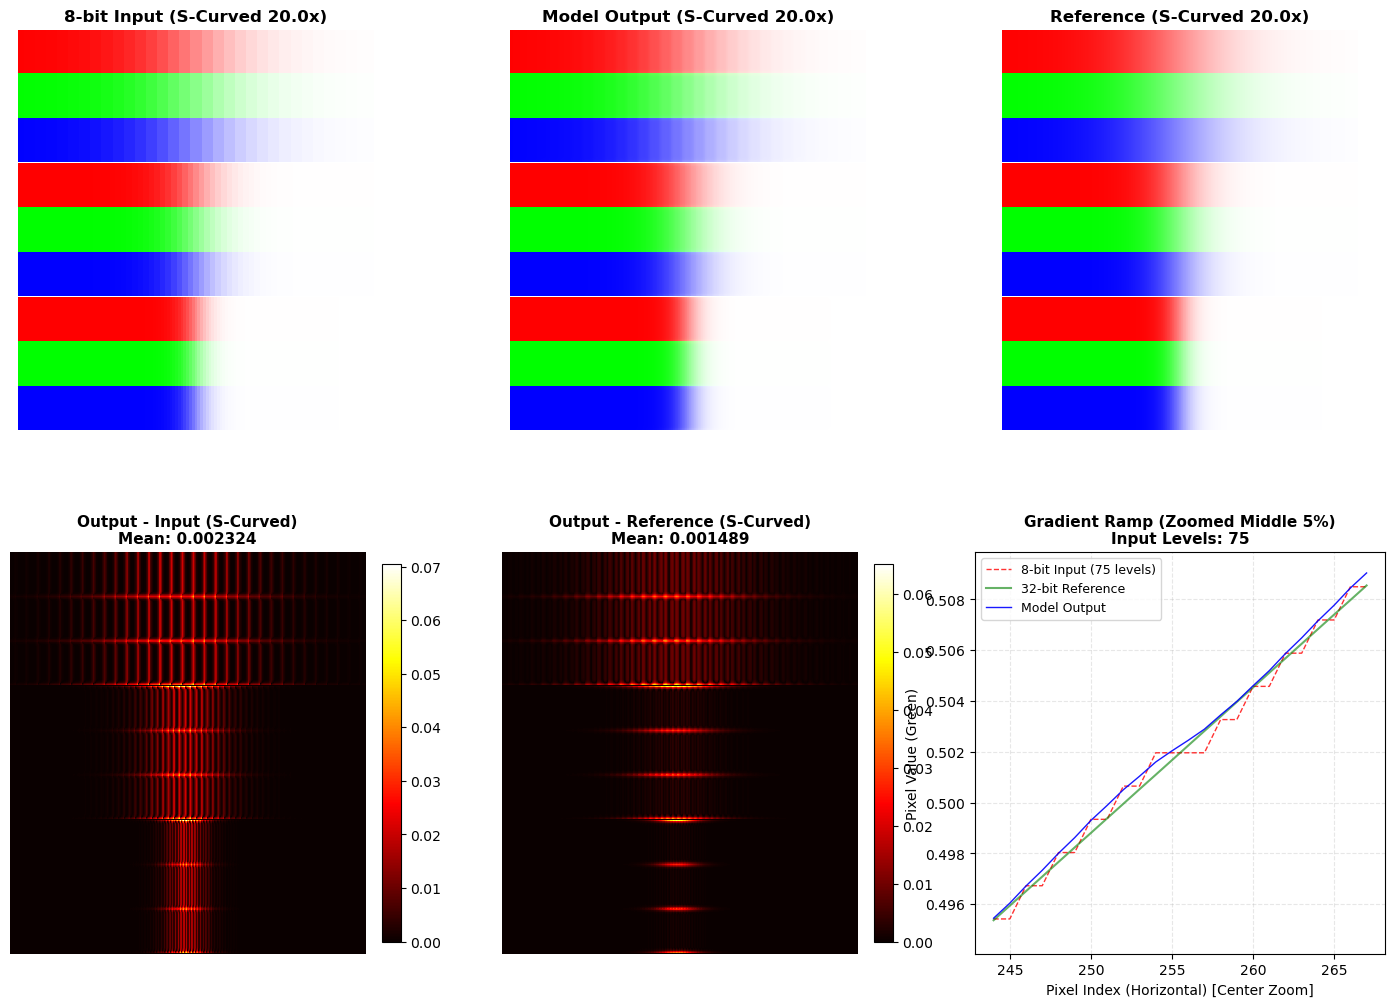

In [12]:
from skimage.restoration import denoise_tv_chambolle

# Total Variation (TV) Denoising Implementation
# TV denoising is an optimization approach that minimizes the total variation of the image.
# It is excellent at removing small noise while preserving sharp edges.

def apply_tv_bde(img: np.ndarray, weight: float = 0.1) -> np.ndarray:
    """
    Apply Total Variation (TV) denoising to a [3, H, W] float32 image.
    In scikit-image, weight controls the trade-off between smoothing and data fidelity.
    Higher weight = more smoothing.
    """
    # scikit-image expects [H, W, 3] for multi-channel TV denoising
    img_hwc = np.transpose(img, (1, 2, 0))
    
    # Apply TV Chambolle denoising
    denoised_hwc = denoise_tv_chambolle(img_hwc, weight=weight, channel_axis=-1)
    
    return np.transpose(denoised_hwc, (2, 0, 1))

# 1. Run the TV denoising on our 8-bit quantized simulation
# We use a relatively high weight to aggressively smooth the staircase artifacts
grad_tv_output = apply_tv_bde(grad_8u_sim, weight=0.01)

# 2. Visualize using our helper (strength=20.0 for comparison with Bilateral)
visualize_bde_results(grad_8u_sim, grad_tv_output, grad_32f, strength=20.0, 
                       titles=["INPUT (8-bit)", "OUTPUT (TV Denoising)", "TARGET (32-bit Ref)"])

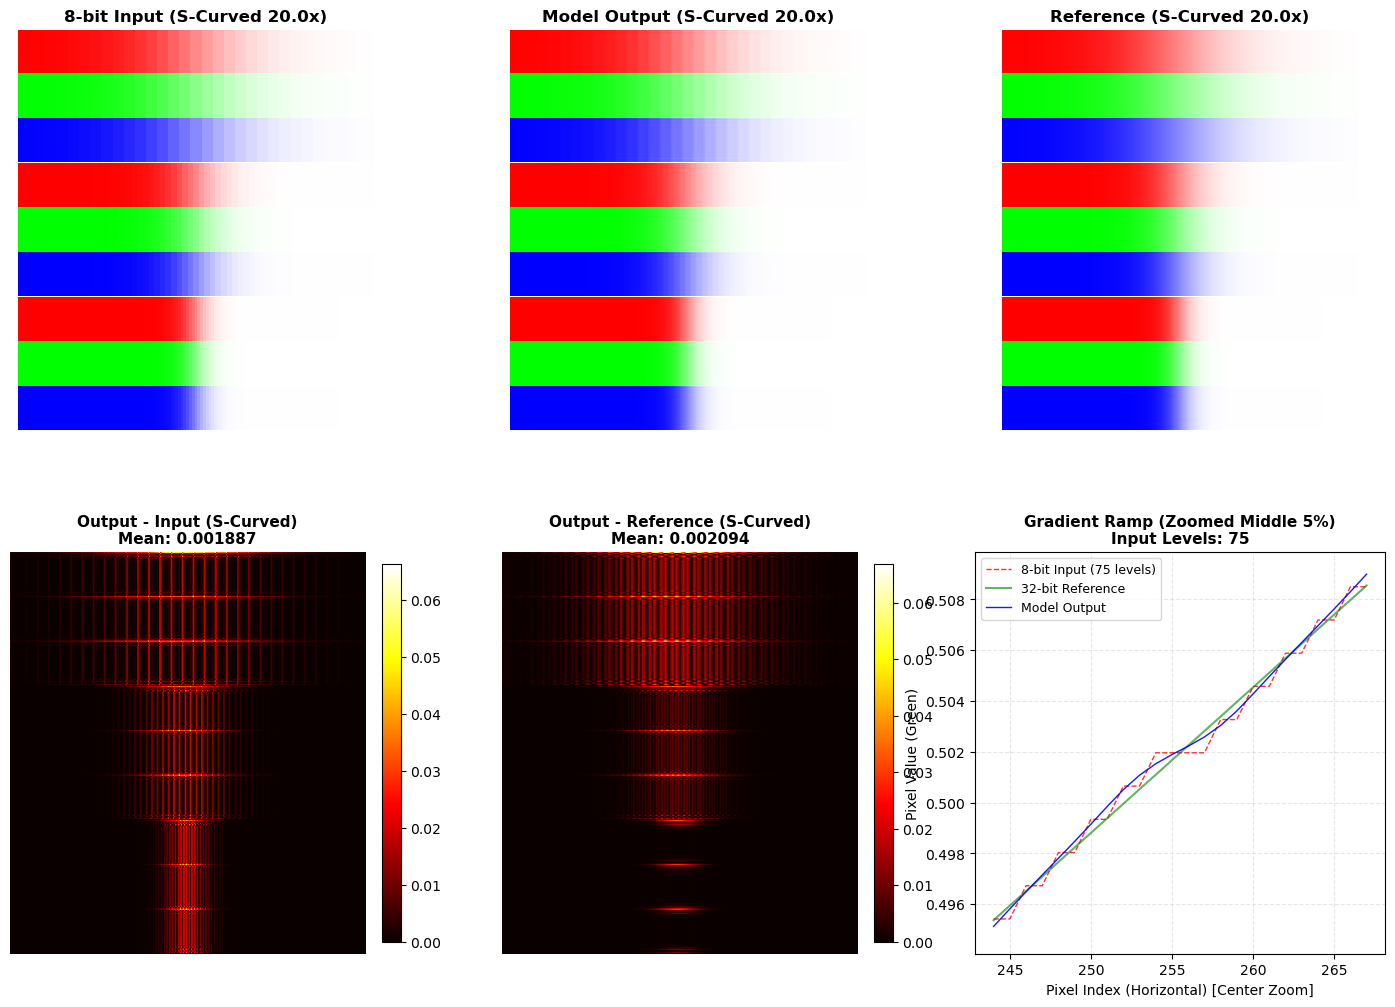

In [13]:
import pywt

# Stationary Wavelet Transform (SWT) BDE Implementation
# Unlike the Discrete Wavelet Transform (DWT), SWT is translation-invariant 
# (no downsampling), which is critical for image restoration to avoid aliasing.

def apply_swt_bde(img: np.ndarray, wavelet: str = 'db2', level: int = 2, threshold: float = 0.01) -> np.ndarray:
    """
    Apply SWT-based denoising to a [3, H, W] float32 image.
    Uses soft-thresholding on high-frequency coefficients to smooth quantization steps.
    """
    # SWT requires dimensions to be divisible by 2^level
    c, h, w = img.shape
    pad_h = (2**level - h % 2**level) % 2**level
    pad_w = (2**level - w % 2**level) % 2**level
    
    img_padded = np.pad(img, ((0,0), (0, pad_h), (0, pad_w)), mode='reflect')
    
    denoised_channels = []
    for ch in range(c):
        # Perform SWT: returns list of (cA_n, (cH_n, cV_n, cD_n), ..., (cH_1, cV_1, cD_1))
        coeffs = pywt.swt2(img_padded[ch], wavelet, level)
        
        new_coeffs = []
        for i, (cA, (cH, cV, cD)) in enumerate(coeffs):
            # Soft-threshold high-frequency components
            # Quantization 'steps' manifest as high-frequency noise
            cH_t = pywt.threshold(cH, threshold, mode='soft')
            cV_t = pywt.threshold(cV, threshold, mode='soft')
            cD_t = pywt.threshold(cD, threshold, mode='soft')
            new_coeffs.append((cA, (cH_t, cV_t, cD_t)))
            
        # Inverse SWT
        denoised_ch = pywt.iswt2(new_coeffs, wavelet)
        denoised_channels.append(denoised_ch)
    
    output = np.stack(denoised_channels)
    
    # Remove padding
    return np.clip(output[:, :h, :w], 0, 1)

# 1. Run the SWT BDE
grad_swt_output = apply_swt_bde(grad_8u_sim, wavelet='db4', level=2, threshold=0.005)

# 2. Visualize using our helper
visualize_bde_results(grad_8u_sim, grad_swt_output, grad_32f, strength=20.0,
                       titles=["INPUT (8-bit)", "OUTPUT (SWT Denoising)", "TARGET (32-bit Ref)", "DIFFERENCE (x10)"])

In [14]:
from src.metrics import compute_psnr, compute_ssim, compute_lpips

# Dictionary of our results for comparison
results = {
    "Original 8-bit": grad_8u_sim,
    "Bilateral": grad_bde_output,
    "TV Denoising": grad_tv_output,
    "SWT Denoising": grad_swt_output
}

print(f"{'Method':<20} | {'PSNR (dB)':<10} | {'SSIM':<10} | {'LPIPS':<10}")
print("-" * 60)

for name, output in results.items():
    p = compute_psnr(output, grad_32f)
    s = compute_ssim(output, grad_32f)
    # LPIPS might be slow on the first run as it downloads model weights
    l = compute_lpips(output, grad_32f)
    print(f"{name:<20} | {p:<10.2f} | {s:<10.4f} | {l:<10.4f}")

Method               | PSNR (dB)  | SSIM       | LPIPS     
------------------------------------------------------------
Original 8-bit       | 60.71      | 0.9992     | 0.0029    
Bilateral            | 68.84      | 0.9999     | 0.0001    
TV Denoising         | 59.13      | 0.9999     | 0.0002    
SWT Denoising        | 61.22      | 0.9997     | 0.0004    
